In [77]:
# Import required libraries for data manipulation, visualization, and analysis
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [78]:
# Load the heart disease dataset from CSV file
from pathlib import Path
df = pd.read_csv(Path("..") / "data" / "heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA + Data Cleaning

In [79]:
# Display all column names in the dataset
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [80]:
# Check dataset dimensions (rows, columns)
df.shape

(918, 12)

In [81]:
# Display data types and non-null counts for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [82]:
# Statistical summary of numerical columns (mean, std, min, max, quartiles)
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [83]:
# Check for missing values in each column
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

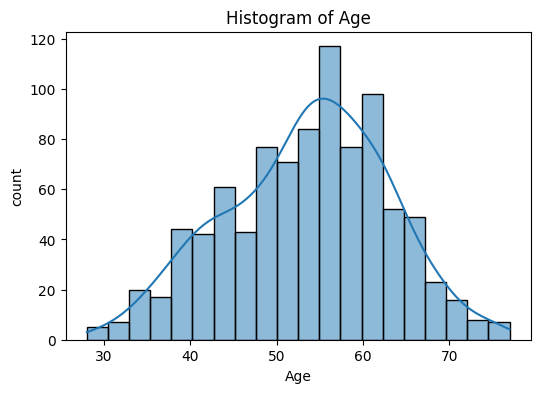

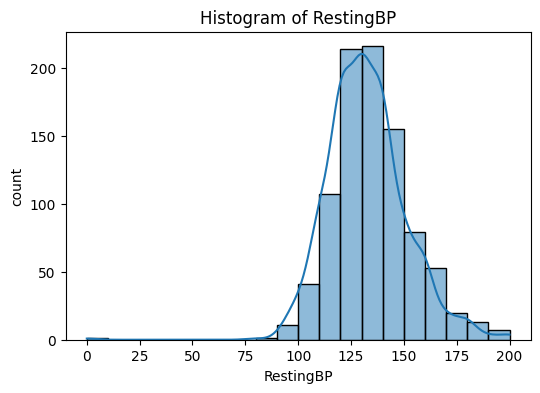

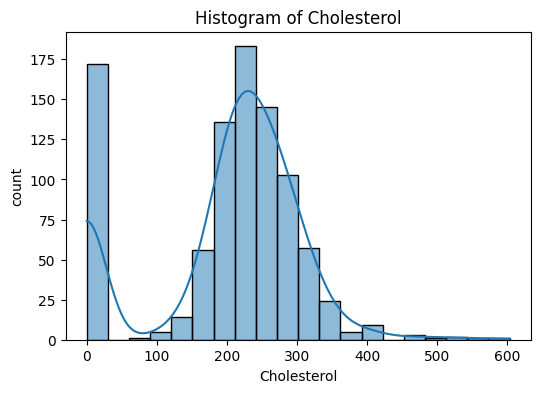

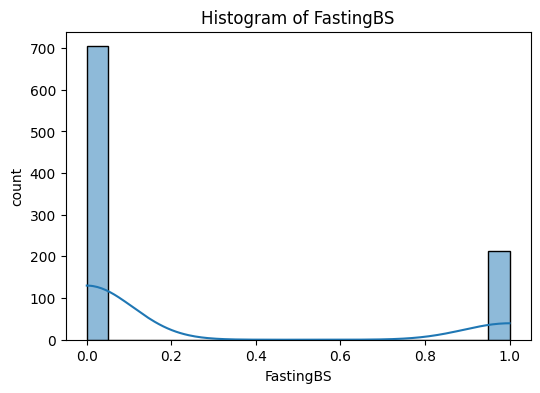

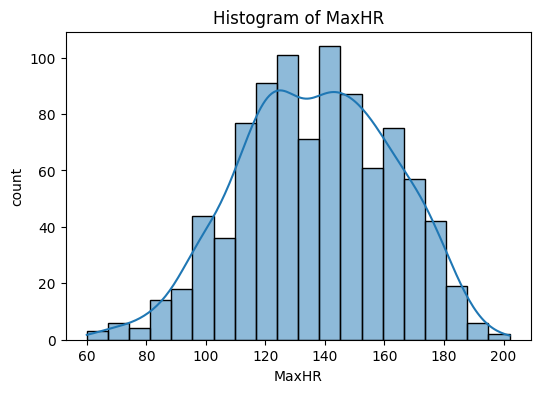

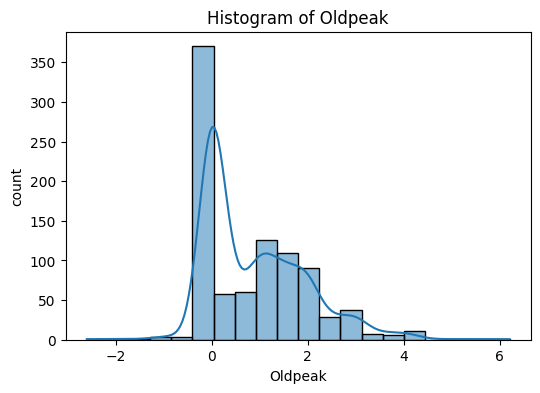

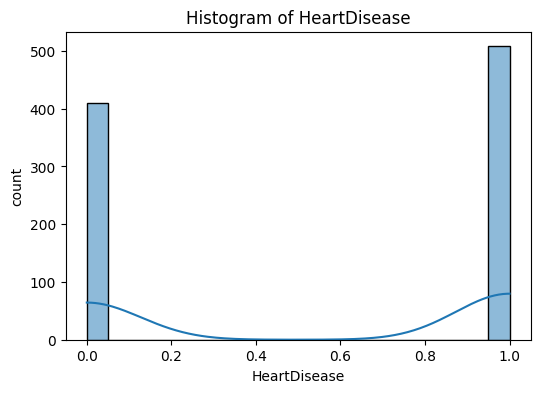

In [84]:
# Visualize distribution of numeric columns using histograms with KDE
numeric_columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde = True, bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

<Axes: xlabel='FastingBS', ylabel='count'>

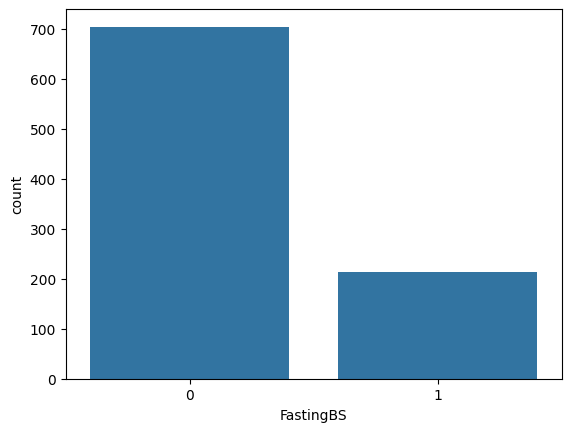

In [85]:
# Count plot for FastingBS (Fasting Blood Sugar) - binary feature
sns.countplot(x = df['FastingBS'])

<Axes: xlabel='HeartDisease', ylabel='count'>

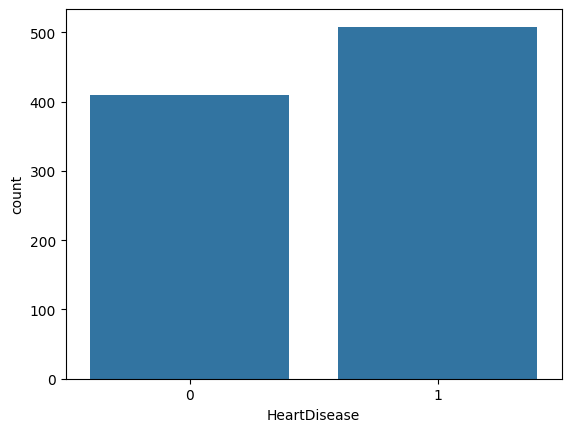

In [86]:
# Count plot for target variable - HeartDisease (0 = No, 1 = Yes)
sns.countplot(x = df['HeartDisease'])

<Axes: >

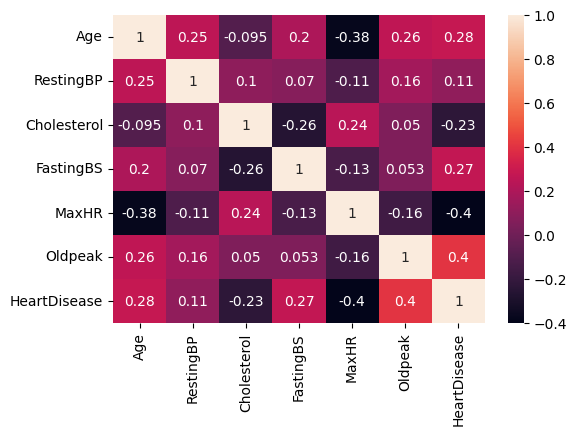

In [87]:
# Correlation heatmap to identify relationships between numeric features
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)

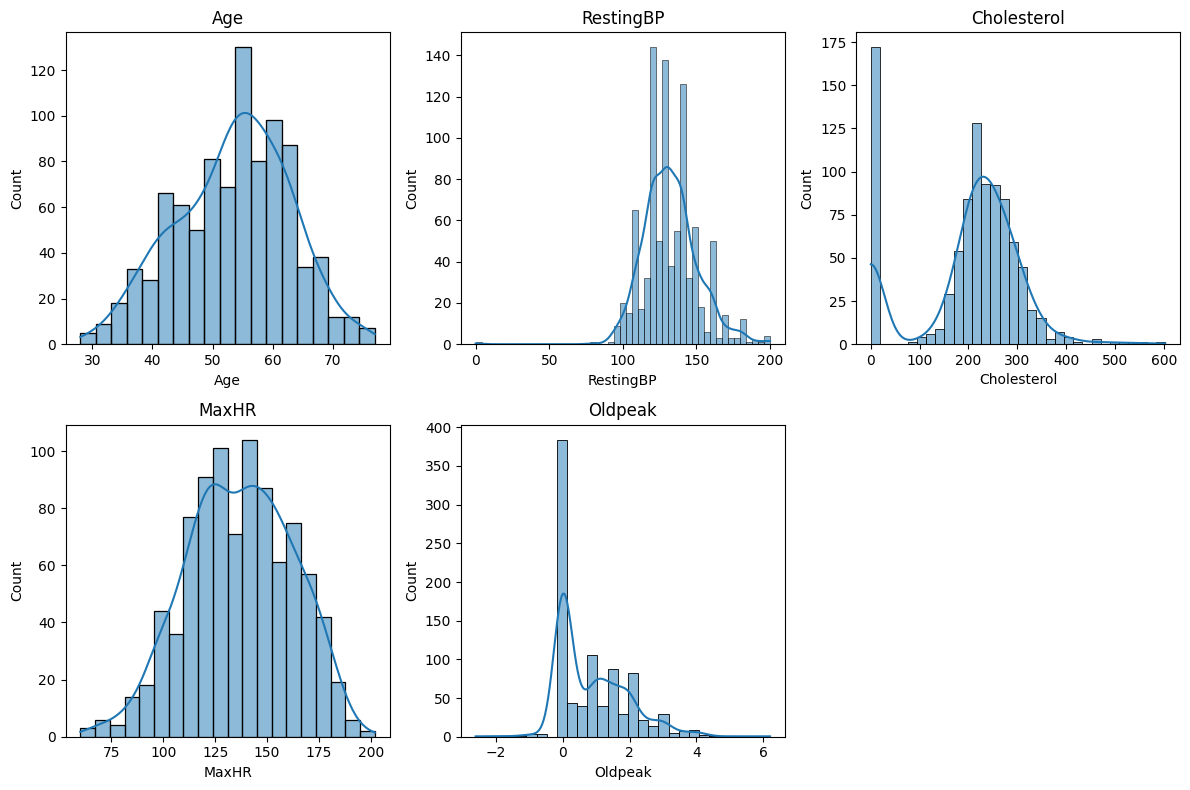

In [88]:
# Grid of histograms for key numeric features (before cleaning)
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(12, 8))
for index, col in enumerate(num_cols, start=1):
    plt.subplot(2, 3, index)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [89]:
# Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [90]:
# Check class distribution of target variable
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [91]:
# Inspect Cholesterol values - identify zero values that need imputation
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [92]:
# Calculate mean cholesterol (excluding zero values) for imputation
cholesterol_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
cholesterol_mean

np.float64(244.6353887399464)

In [93]:
# Impute zero cholesterol values with mean and round to 2 decimal places
df['Cholesterol'] = df['Cholesterol'].replace(0, cholesterol_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [94]:
# Impute zero RestingBP values with mean (same approach as Cholesterol)
restingBP_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, restingBP_mean)
df['RestingBP'] = df['RestingBP'].round(2)

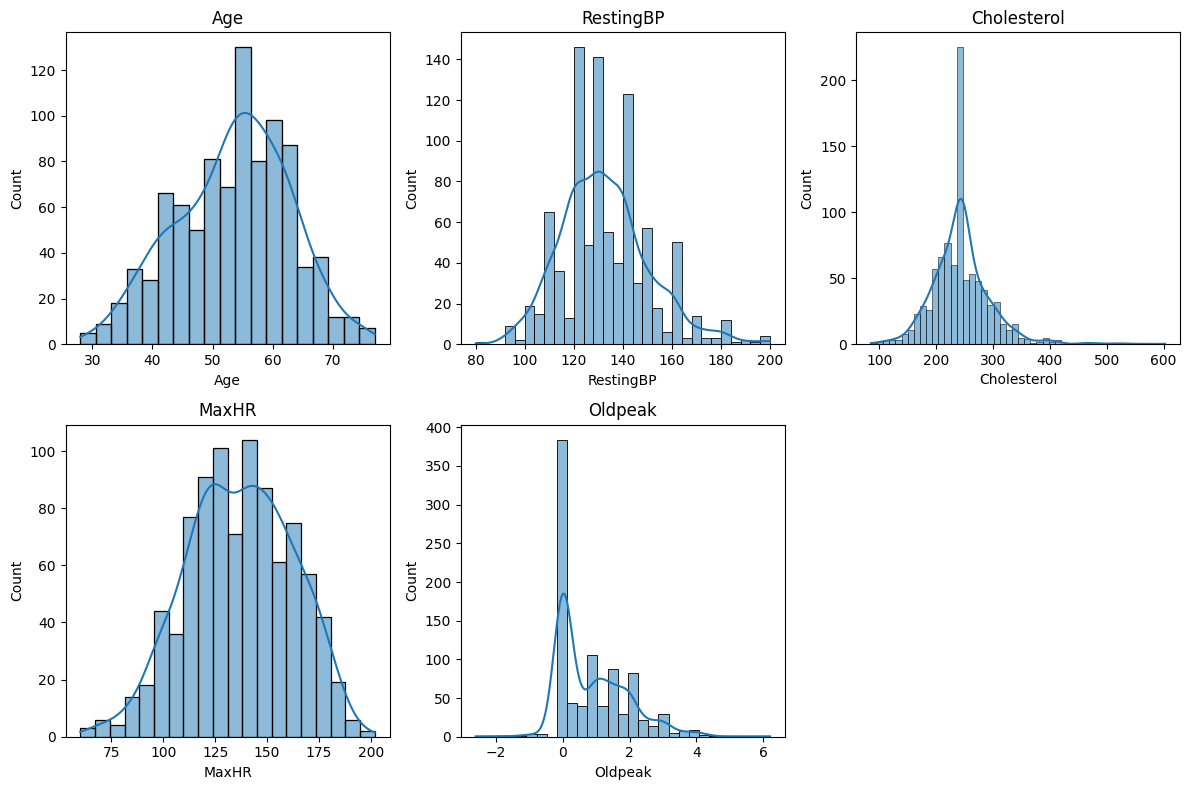

In [95]:
# Verify distributions after data cleaning (imputation)
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(12, 8))
for index, col in enumerate(num_cols, start=1):
    plt.subplot(2, 3, index)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

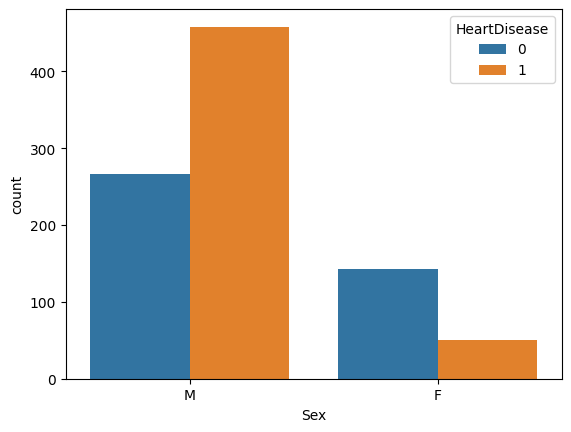

In [96]:
# Analyze relationship between Sex and HeartDisease
sns.countplot(x = df['Sex'], hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

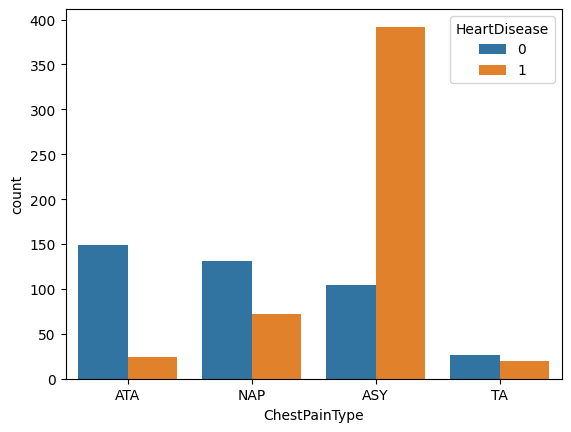

In [97]:
# Analyze relationship between ChestPainType and HeartDisease
sns.countplot(x = df['ChestPainType'], hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

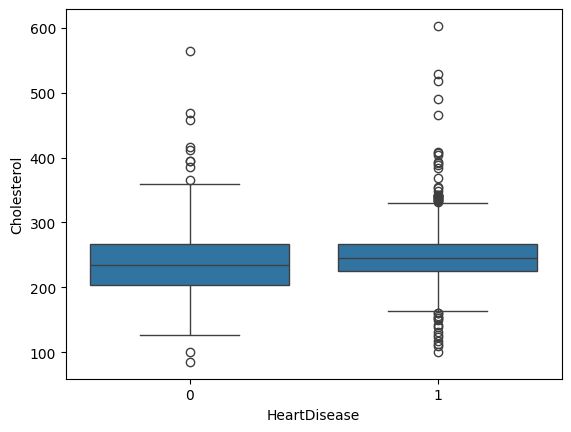

In [98]:
# Boxplot: Cholesterol distribution by HeartDisease status
sns.boxplot(x = df['HeartDisease'], y = df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

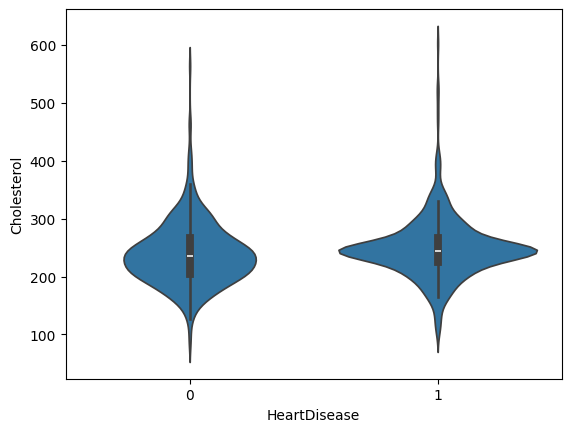

In [99]:
# Violin plot: Cholesterol distribution by HeartDisease (shows density)
sns.violinplot(x = 'HeartDisease', y = 'Cholesterol', data = df)

# Data Preprocessing

In [100]:
# One-hot encode categorical columns (drop_first to avoid multicollinearity)
df_encode = pd.get_dummies(df, drop_first=True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [101]:
# Convert all columns to integer type (boolean dummies become 0/1)
df_encode = df_encode.astype(int)

In [102]:
# Display encoded dataframe structure
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [103]:
# Standardize numerical features using StandardScaler (mean=0, std=1)
from sklearn.preprocessing import StandardScaler
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scalar = StandardScaler()
df_encode[cols] = scalar.fit_transform(df_encode[cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [104]:
# Pearson correlation analysis: measure linear relationship between features and target
from scipy.stats import pearsonr

selected_features = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak',	
                     'Sex_M','ChestPainType_ATA','ChestPainType_NAP',
                     'ChestPainType_TA','RestingECG_Normal','RestingECG_ST','ExerciseAngina_Y',
                     'ST_Slope_Flat','ST_Slope_Up']

correlation = {
    feature: pearsonr(df_encode[feature], df_encode['HeartDisease'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlation.items()), columns = ['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
13,ST_Slope_Flat,0.554134
12,ExerciseAngina_Y,0.494282
5,Oldpeak,0.392385
6,Sex_M,0.305445
0,Age,0.282039
3,FastingBS,0.267291
1,RestingBP,0.117909
11,RestingECG_ST,0.102527
2,Cholesterol,0.092586
9,ChestPainType_TA,-0.054790


In [105]:
# Categorical columns from selected_features (one-hot encoded binary columns)
categorical_cols = [col for col in selected_features if df_encode[col].nunique() == 2]
categorical_cols

['FastingBS',
 'Sex_M',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_Y',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [106]:
# Chi-square test to evaluate categorical feature association with HeartDisease
# p-value < alpha suggests the feature and target are statistically dependent.
from scipy.stats import chi2_contingency

alpha = 0.05
chi2_results = {}

for col in categorical_cols:
    contingency = pd.crosstab(df_encode[col], df_encode['HeartDisease'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
ST_Slope_Up,352.823905,0.0,Reject Null (Keep Feature)
ST_Slope_Flat,279.659914,0.0,Reject Null (Keep Feature)
ExerciseAngina_Y,222.259383,0.0,Reject Null (Keep Feature)
ChestPainType_ATA,146.236323,0.0,Reject Null (Keep Feature)
Sex_M,84.145101,0.0,Reject Null (Keep Feature)
FastingBS,64.320679,0.0,Reject Null (Keep Feature)
ChestPainType_NAP,40.608711,0.0,Reject Null (Keep Feature)
RestingECG_ST,9.135266,0.002507,Reject Null (Keep Feature)
RestingECG_Normal,7.327532,0.006791,Reject Null (Keep Feature)
ChestPainType_TA,2.273802,0.131577,Accept Null (Drop Feature)


In [107]:
# Build final feature list: keep categorical features that passed chi-square test
final_categorical_cols = chi2_df[chi2_df['Decision'] == 'Reject Null (Keep Feature)'].index.tolist()

# Combine numerical and statistically significant categorical features
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
final_features = numerical_cols + final_categorical_cols
final_features.append('HeartDisease')

In [108]:
# Create final dataframe with selected features for model training
final_df = df_encode[final_features]
final_df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,ST_Slope_Up,ST_Slope_Flat,ExerciseAngina_Y,ChestPainType_ATA,Sex_M,FastingBS,ChestPainType_NAP,RestingECG_ST,RestingECG_Normal,HeartDisease
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,1,0,0,1,1,0,0,0,1,0
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,0,1,0,0,0,0,1,0,1,1
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,1,0,0,1,1,0,0,1,0,0
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,0,1,1,0,0,0,0,0,1,1
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,1,0,0,0,1,0,1,0,1,0


# Summary

## Objective
Prepare the Heart Disease dataset for machine learning by performing EDA, data cleaning, feature engineering, and statistical feature selection.

## Major Steps

### 1. Data Loading & Initial Exploration
- Loaded heart.csv dataset with 918 records and 12 features
- Examined data types, shape, and basic statistics
- Checked for missing values and duplicates

### 2. Exploratory Data Analysis (EDA)
- Visualized distributions of numeric features using histograms
- Analyzed target variable (HeartDisease) distribution
- Created correlation heatmap to identify feature relationships
- Explored categorical features (Sex, ChestPainType) vs HeartDisease

### 3. Data Cleaning
- Identified zero values in Cholesterol and RestingBP as invalid
- Imputed zeros with mean values (excluding zeros) for both columns
- Verified distributions after imputation

### 4. Data Preprocessing
- One-hot encoded categorical features (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope)
- Used `drop_first=True` to avoid multicollinearity
- Standardized numerical features using StandardScaler

### 5. Feature Selection
- **Pearson Correlation**: Measured linear relationship between features and target
- **Chi-Square Test**: Evaluated statistical dependence of categorical features with HeartDisease
- Kept features with p-value < 0.05 (statistically significant)

### 6. Final Dataset
- Combined numerical features + statistically significant categorical features
- Created `final_df` ready for model training

## Output
- `final_df`: Cleaned, encoded, and scaled dataset with selected features for heart disease prediction